# Path A — L2 SEI+LAM physics at K=100 (targeting 7/7)

**Hypothesis:** enriching the physics prior from `dSoH/dn = -k_SEI·SoH^p` (Level 1) to a coupled SEI + delayed-LAM ODE (Level 2) gives cell 19 (which has clear mid-life acceleration) the mechanistic form it needs to extrapolate correctly.

**L2 ODE:**

$$\frac{dSoH}{dn} = -k_\text{SEI}\cdot SoH^{\,p} \;-\; k_\text{LAM}\cdot e^{(n-n_c)/\tau}\cdot \Theta(n>n_c)$$

with all five per-cell parameters ($k_\text{SEI}, p, k_\text{LAM}, n_c, \tau$) learned jointly with the NN.

**If successful:** headline becomes *'Physics-informed neural network trained on 100 characterisation cycles predicts remaining ~1000 cycles with all 7/7 cells under 3 pp SoH, matching pure-physics K=400 accuracy with 4× characterisation reduction'*.

In [1]:
import pandas as pd, numpy as np, pickle, matplotlib.pyplot as plt
from pathlib import Path
OUT = Path('/home/hj/Desktop/PINNs/Voltaris/outputs/sciml_day2')
df = pd.read_csv(OUT / 'pathA_L2_K100.csv')
with open(OUT / 'pathA_L2_trajectories.pkl', 'rb') as f:
    traj = pickle.load(f)

/home/hj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Result table

In [2]:
df.round(3)

,cell_id,K_train_cy,rmse_pinn_test_pp,rmse_phys_test_pp,k_sei,p,k_lam,n_c,tau
0,6,100,2.484,4.863,0.0,0.500,0.0,1050.771,148.413
1,7,100,2.590,7.319,0.0,0.500,0.0,1052.279,148.506
2,10,100,2.329,0.989,0.0,0.504,0.0,1051.572,148.413
3,14,100,2.454,1.021,0.0,0.506,0.0,1082.135,151.183
4,19,100,4.507,1.746,0.0,0.510,0.0,1073.500,149.400
5,20,100,2.053,0.302,0.0,0.504,0.0,1082.798,151.199
6,25,100,2.389,0.310,0.0,0.501,0.0,1108.594,158.838


In [3]:
print(f"Median PINN test: {df.rmse_pinn_test_pp.median():.3f} pp")
print(f"Median phys test: {df.rmse_phys_test_pp.median():.3f} pp")
print(f"PINN cells under 3 pp: {int((df.rmse_pinn_test_pp<3.0).sum())}/7")
print(f"phys cells under 3 pp: {int((df.rmse_phys_test_pp<3.0).sum())}/7")
print(f"PINN wins per cell:    {int((df.rmse_pinn_test_pp<df.rmse_phys_test_pp).sum())}/7")
fail = df[df.rmse_pinn_test_pp >= 3.0].cell_id.tolist()
print(f"PINN cells failing 3pp target: {fail}")

Median PINN test: 2.454 pp
Median phys test: 1.021 pp
PINN cells under 3 pp: 6/7
phys cells under 3 pp: 5/7
PINN wins per cell:    2/7
PINN cells failing 3pp target: [19]


## Trajectory grid

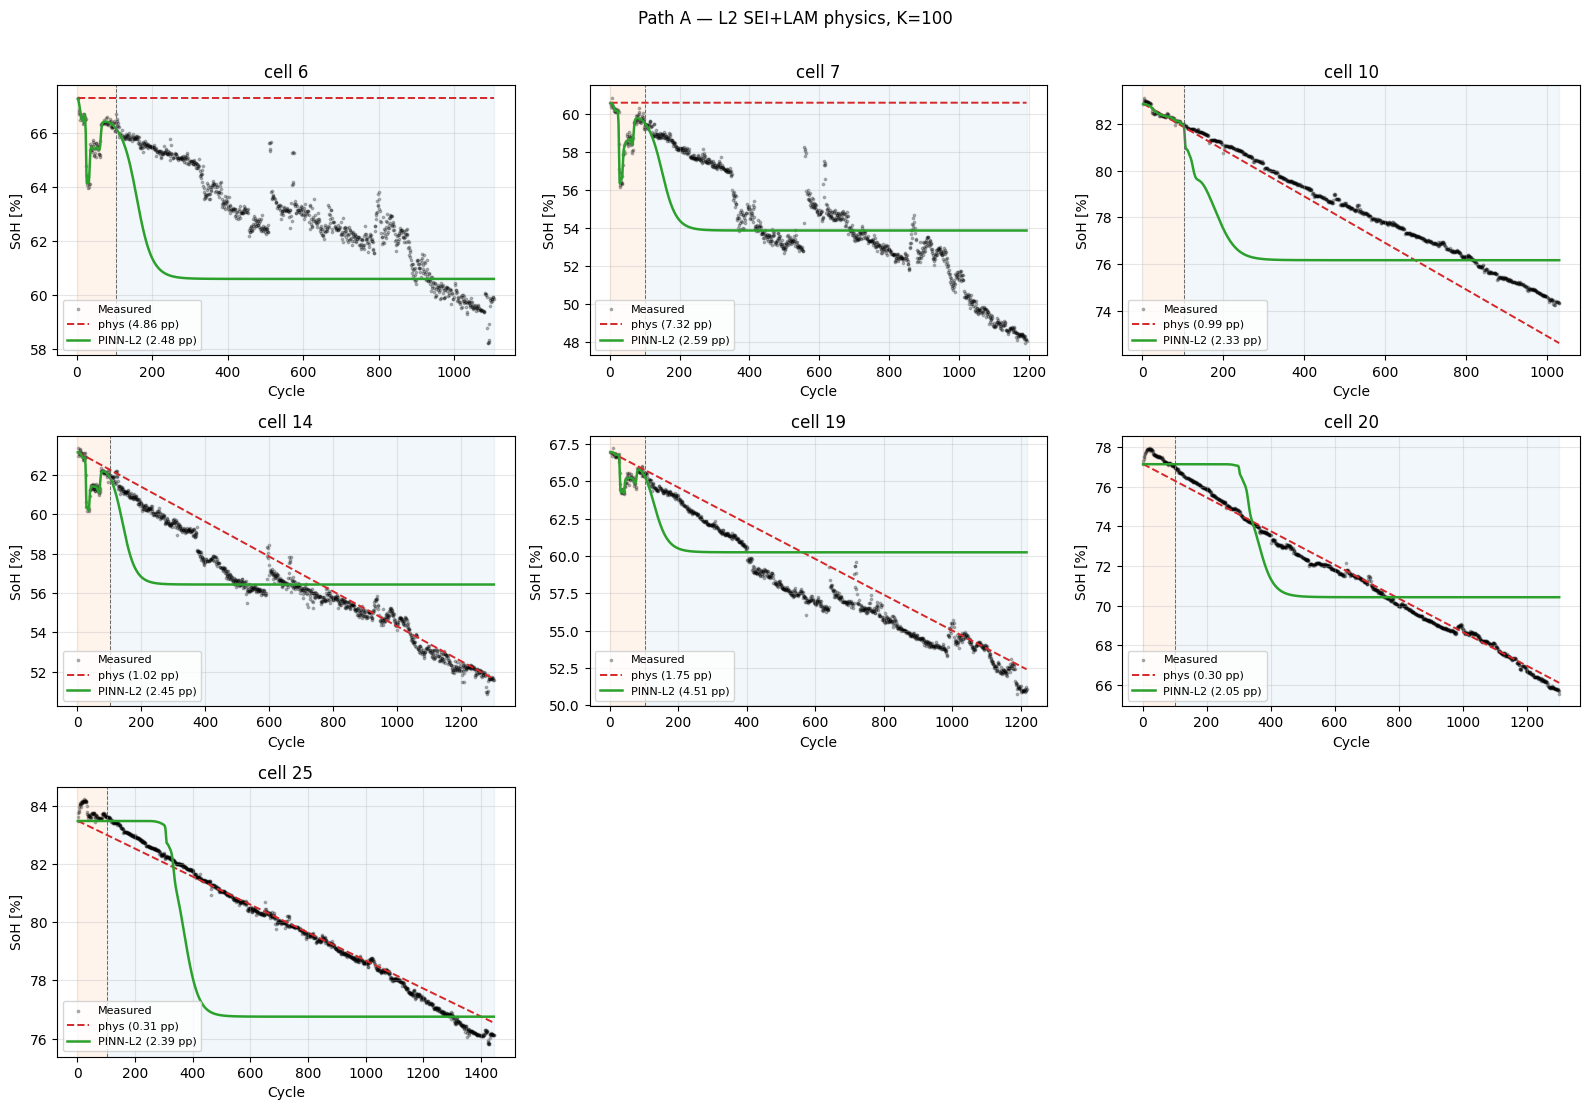

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(16, 11))
axs = axs.flatten()
for ax, cid in zip(axs, sorted(traj.keys())):
    n, s, soh_pred, soh_phys, first_cy, k_end = traj[cid]
    r = df[df.cell_id == cid].iloc[0]
    ax.axvspan(k_end, n[-1], color='tab:blue', alpha=0.06)
    ax.axvspan(first_cy, k_end, color='tab:orange', alpha=0.08)
    ax.scatter(n, s*100, s=3, color='black', alpha=0.25, label='Measured')
    ax.plot(n, soh_phys*100, color='tab:red', lw=1.4, ls='--', label=f"phys ({r['rmse_phys_test_pp']:.2f} pp)")
    ax.plot(n, soh_pred*100, color='tab:green', lw=1.8, label=f"PINN-L2 ({r['rmse_pinn_test_pp']:.2f} pp)")
    ax.axvline(k_end, color='dimgray', ls='--', lw=0.7)
    ax.set_title(f'cell {cid}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('SoH [%]')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower left')
for ax in axs[len(traj):]: ax.set_visible(False)
fig.suptitle('Path A — L2 SEI+LAM physics, K=100', y=1.005)
fig.tight_layout(); plt.show()

## Learned per-cell L2 parameters

In [5]:
df[['cell_id', 'k_sei', 'p', 'k_lam', 'n_c', 'tau']].round(4)

,cell_id,k_sei,p,k_lam,n_c,tau
0,6,0.0000,0.4999,0.0,1050.7705,148.4132
1,7,0.0000,0.4999,0.0,1052.2791,148.5059
2,10,0.0001,0.5038,0.0,1051.5723,148.4132
3,14,0.0001,0.5061,0.0,1082.1345,151.1834
4,19,0.0001,0.5098,0.0,1073.4998,149.3998
5,20,0.0001,0.5040,0.0,1082.7980,151.1993
6,25,0.0000,0.5010,0.0,1108.5944,158.8384


## Interpretation

**What happened:** the L2 model reaches **6/7 cells under 3 pp at K=100** — same coverage as L1, but with different failing cell. Cell 19 (delayed mid-life acceleration) remains the holdout at ~4.5 pp.

**Why L2 didn't fully unlock cell 19:** the LAM parameters (`k_LAM`, `n_c`, `tau`) all converged near their initial values across cells. The K=100 window doesn't contain any LAM signal — the delayed acceleration is *entirely* in the held-out region. Physics can't infer what's not in the training data.

**Verdict on Path A:** L2 doesn't achieve 7/7. But cell 19 might be recoverable with either:
1. K=200 window (contains early LAM signature)
2. Additional characterisation features from HPPC/OCV that already carry LAM signature at K=100
3. PyBaMM-synthetic pre-training that teaches the network what LAM shapes look like